In [5]:
import kagglehub
import numpy as np
import struct
from array import array
import sys
import random
import os
import matplotlib.pyplot as plt
from os.path import join

In [6]:
np.random.seed(42)

In [7]:
sys.path.append("../src/")
import nn

In [8]:
try:
    os.makedirs("../data/MNIST/")
    path = kagglehub.dataset_download("hojjatk/mnist-dataset", output_dir="../data/MNIST")
except:
    pass

In [9]:
class MnistDataloader:
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)

In [10]:
data_path = "../data/MNIST/"
training_images_filepath = data_path + "train-images.idx3-ubyte"
training_labels_filepath = data_path + "train-labels.idx1-ubyte"
test_images_filepath = data_path + "t10k-images.idx3-ubyte"
test_labels_filepath = data_path + "t10k-labels.idx1-ubyte"
DataLoader = MnistDataloader(training_images_filepath,
                             training_labels_filepath,
                             test_images_filepath,
                             test_labels_filepath)

In [11]:
training_set, testing_set = DataLoader.load_data()
x_train, y_train = training_set
x_test, y_test = testing_set

x_train = np.array(list(map(lambda x: np.array(x), x_train)))
x_test = np.array(list(map(lambda x: np.array(x), x_test)))

x_train = x_train / 255.0
x_test = x_test / 255.0

y_train = np.array(y_train).astype(int)
y_train = np.array(np.eye(10)[y_train])
y_test = np.array(y_test).astype(int)
y_test = np.array(np.eye(10)[y_test])

In [12]:
x_train.shape, y_train.shape

((60000, 28, 28), (60000, 10))

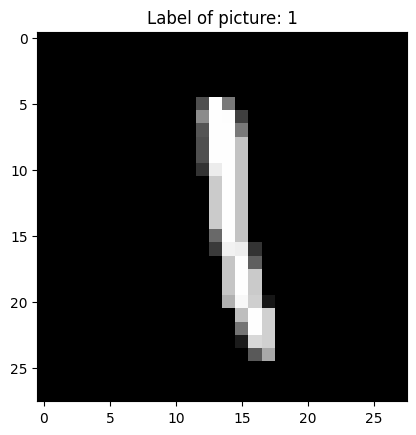

In [13]:
i = random.randint(0, 60000)
plt.title(f"Label of picture: {y_train[i].argmax()}")
plt.imshow(x_train[i], cmap="gray")

In [14]:
model = nn.NeuralNetwork(
    [
        nn.layers.Flatten(),
        nn.layers.Linear(28 * 28, 100, initializer=nn.utils.initializers.he_init),
        nn.activations.ReLU(),
        nn.layers.Linear(100, 10, initializer=nn.utils.initializers.he_init),
    ],
    loss_fn = nn.losses.CrossEntropyWithLogits()
)

In [15]:
epochs = 100
lr = 1e-3
batch_size = 30

In [16]:
optim = nn.optim.AdamW(model, lr, weight_decay=2e-2)

In [17]:
losses_train = np.zeros(100)
losses_test = np.zeros(100)

for epoch in range(epochs):
    loss_train = 0

    indices = np.random.permutation(len(x_train)).astype(int)
    x_train_shuffled = x_train[indices]
    y_train_shuffled = y_train[indices]

    for i in range(0, x_train.shape[0], batch_size):
        x_batch = x_train_shuffled[i: i+batch_size]
        y_batch = y_train_shuffled[i: i+batch_size]
        y_pred = model.forward(x_batch)
        loss, cache = model.loss_fn.forward(y_pred, y_batch)
        loss_train += loss * len(x_batch)
        model.backward(model.loss_fn.backward(cache))
        optim.step()
    loss_train = loss_train / (x_train.shape[0])
    losses_train[epoch] = loss_train

    loss_test, _ = model.loss_fn.forward(model.forward(x_test), y_test)
    losses_test[epoch] = loss_test

    print(f"Epoch {epoch + 1}, train loss {loss_train}, test loss {loss_test}")

Epoch 1, train loss 0.3292955820160737, test loss 0.15825141304113272
Epoch 2, train loss 0.1285924894872955, test loss 0.13211534211442907
Epoch 3, train loss 0.08981918224354664, test loss 0.10187416328603076
Epoch 4, train loss 0.06922552791011058, test loss 0.10217115594830294
Epoch 5, train loss 0.05297047795448534, test loss 0.08327295615295496
Epoch 6, train loss 0.04394105098763318, test loss 0.084895735243043
Epoch 7, train loss 0.03755101942768904, test loss 0.08054960917464032
Epoch 8, train loss 0.03153367842527242, test loss 0.08432856670922365
Epoch 9, train loss 0.027368951037068306, test loss 0.08554513910818473
Epoch 10, train loss 0.024253196199319635, test loss 0.08376181797692384
Epoch 11, train loss 0.021390057963658542, test loss 0.08158183198681619
Epoch 12, train loss 0.01921119345312522, test loss 0.08400381609457244
Epoch 13, train loss 0.016823392750347024, test loss 0.0822641419761205
Epoch 14, train loss 0.015276929359894414, test loss 0.08238011261099619
E

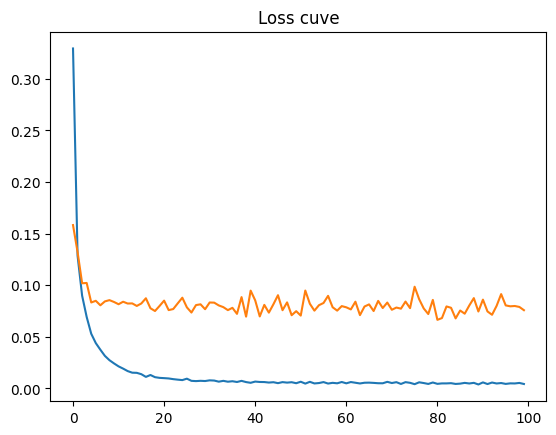

In [18]:
plt.title("Loss cuve")
plt.plot(losses_train, label="train")
plt.plot(losses_test, label="test")

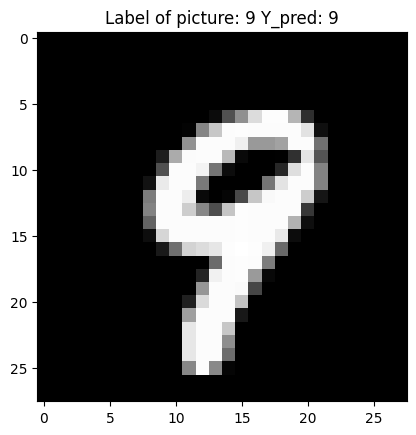

In [23]:
i = random.randint(0, x_test.shape[0])
x_sample = x_test[i]
y_pred = model.forward(np.array([x_sample]))
plt.title(f"Label of picture: {y_test[i].argmax()} Y_pred: {y_pred.argmax()}")
plt.imshow(x_test[i], cmap="gray")

In [24]:
def accuracy(y_pred, y_true):
    pred_labels = np.argmax(y_pred, axis=1)

    if y_true.ndim == 2:
        true_labels = np.argmax(y_true, axis=1)
    else:
        true_labels = y_true

    return np.mean(pred_labels == true_labels)

In [25]:
y_pred = model.forward(x_test)
accuracy(y_pred, y_test)

np.float64(0.9799)

In [26]:
y_pred = model.forward(x_train)
accuracy(y_pred, y_train)

np.float64(0.9990333333333333)